# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Module:** Unsupervised Patient Clustering & Segmentation

### Overview
We perform unsupervised clustering on patient clinical and utilization metrics using K-Means, Agglomerative, DBSCAN, Gaussian Mixture, and Spectral Clustering.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Clustering libraries loaded successfully.')

Clustering libraries loaded successfully.


In [2]:
# Load dataset and preprocess for clustering
df_raw = pd.read_csv(config.DATA_PATH)
df_cluster = df_raw.drop(columns=[c for c in [config.REGRESSION_TARGET, config.CLASSIFICATION_TARGET, 'person_id', 'risk_score'] if c in df_raw.columns])

# Handle missing values
for col in df_cluster.select_dtypes(include='object').columns:
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].mode()[0])
for col in df_cluster.select_dtypes(include=np.number).columns:
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

# One-hot encoding and scaling
df_encoded = pd.get_dummies(df_cluster, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
print('Scaled clustering data shape:', X_scaled.shape)

Scaled clustering data shape: (100000, 69)


/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_37124/1452025377.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_cluster.select_dtypes(include='object').columns:


In [3]:
# Fit clustering models on subsample for efficiency
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

models = {
    'K-Means': KMeans(n_clusters=4, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=4, linkage='ward'),
    'DBSCAN': DBSCAN(eps=1.5, min_samples=5),
    'Gaussian Mixture': GaussianMixture(n_components=4, random_state=42),
    'Spectral Clustering': SpectralClustering(n_clusters=4, random_state=42, affinity='nearest_neighbors')
}

cluster_results = []
for name, model in models.items():
    labels = model.fit_predict(X_sample)
    if len(set(labels)) > 1:
        sil = silhouette_score(X_sample, labels)
        db = davies_bouldin_score(X_sample, labels)
        ch = calinski_harabasz_score(X_sample, labels)
        cluster_results.append({'Algorithm': name, 'Silhouette Score': sil, 'Davies-Bouldin Index': db, 'Calinski-Harabasz Index': ch})
    else:
        print(f'{name} produced 1 cluster.')

df_cluster_res = pd.DataFrame(cluster_results).sort_values(by='Silhouette Score', ascending=False).reset_index(drop=True)
df_cluster_res

DBSCAN produced 1 cluster.


,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,Spectral Clustering,0.145807,2.033011,80.598955
1,K-Means,0.068630,3.974472,160.114995
2,Agglomerative,0.049582,4.122567,111.855726
3,Gaussian Mixture,0.019878,4.831065,110.824754


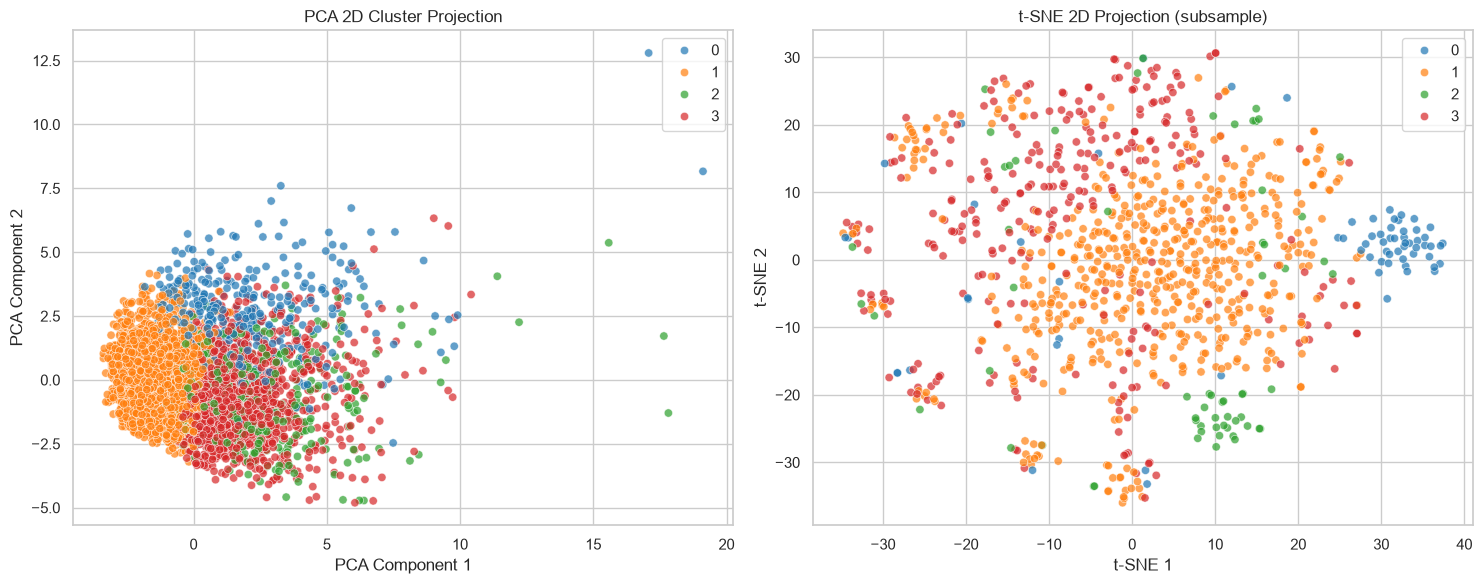

In [4]:
# PCA 2D Visualization & t-SNE Visualization
kmeans_best = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_best = kmeans_best.fit_predict(X_sample)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample[:1000])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_best, palette='tab10', ax=axes[0], alpha=0.7)
axes[0].set_title('PCA 2D Cluster Projection')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_best[:1000], palette='tab10', ax=axes[1], alpha=0.7)
axes[1].set_title('t-SNE 2D Projection (subsample)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()